In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
sns.set_style('darkgrid')
df = pd.read_csv("datasets\\mercc_cleaned.csv")

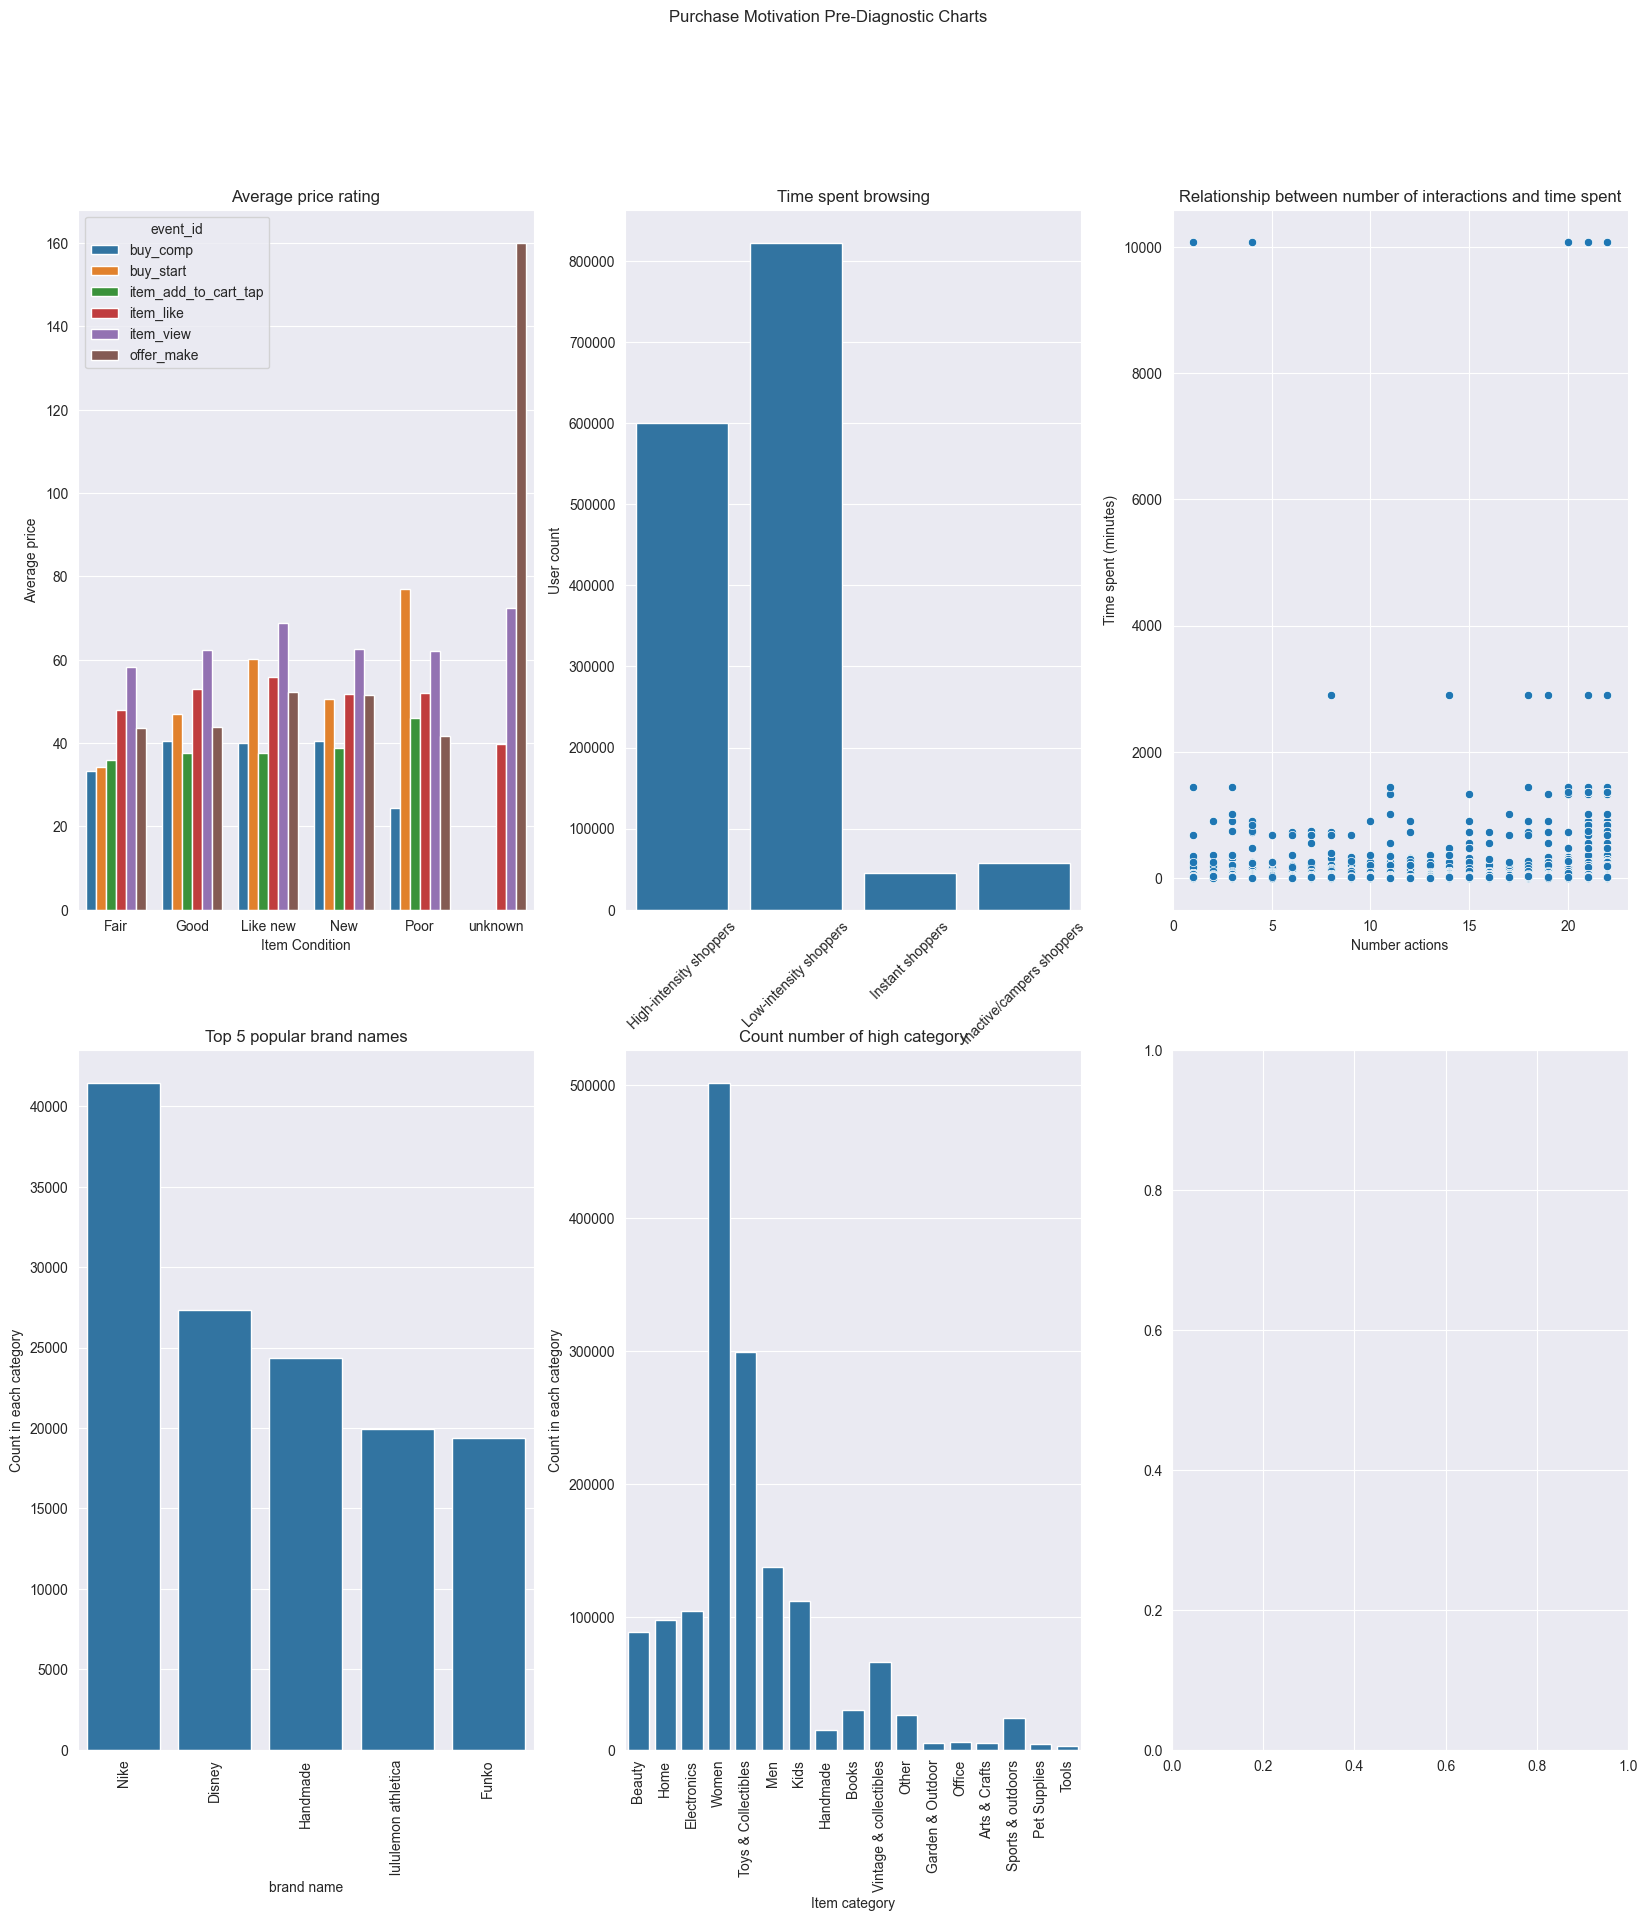

In [10]:
# Data diagnostic
'''
    data in pre-diagnostic are mostly categorized, in ML modeling data transformation will be done
    As reporting categorized data will introduce bias
'''

# Purchase Motivation
avg_price_cat_nested = pd.DataFrame(df.groupby(['item_condition_name','event_id'])['price'].agg(['mean','std'])).reset_index()

fig, axes = plt.subplots(2, 3, figsize=[20,20])
fig.suptitle('Purchase Motivation Pre-Diagnostic Charts')

sns.barplot(x='item_condition_name', y='mean', data=avg_price_cat_nested, ax=axes[0,0], hue='event_id')
axes[0,0].set_title('Average price rating')
axes[0,0].set_xlabel('Item Condition')
axes[0,0].set_ylabel('Average price')

sns.countplot(df,x='shopper_category', ax=axes[0,1])
axes[0,1].set_title('Time spent browsing')
axes[0,1].set_xlabel('Minute spent')
axes[0,1].set_ylabel('User count')
plt.setp(axes[0,1].get_xticklabels(), rotation=45)

sns.scatterplot(x='sequence_length',y='session_length_min', data=df, ax=axes[0,2])
axes[0,2].set_title('Relationship between number of interactions and time spent')
axes[0,2].set_xlabel('Number actions')
axes[0,2].set_ylabel('Time spent (minutes)')

top_brand = pd.DataFrame(df['brand_name'].value_counts()[1:6]).reset_index()

sns.barplot(x='brand_name', y='count', data=top_brand, ax=axes[1,0])
axes[1,0].set_title('Top 5 popular brand names')
axes[1,0].set_xlabel('brand name')
axes[1,0].set_ylabel('Count in each category')
plt.setp(axes[1,0].get_xticklabels(), rotation=90)

sns.countplot(x='c0_name', data=df, ax=axes[1,1])
axes[1,1].set_title('Count number of high category')
axes[1,1].set_xlabel('Item category')
axes[1,1].set_ylabel('Count in each category')
plt.setp(axes[1,1].get_xticklabels(), rotation=90)

plt.savefig('purchase_motivation_diagnostic.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
print('\nAverage price per item condition (Table)')
avg_price_cat_nested


Average price per item condition (Table)


,item_condition_name,event_id,mean,std
0,Fair,buy_comp,33.365854,45.559168
1,Fair,buy_start,34.283582,48.316446
2,Fair,item_add_to_cart_tap,36.041127,77.438118
3,Fair,item_like,48.024567,96.392233
4,Fair,item_view,58.215276,128.730667
5,Fair,offer_make,43.543527,66.168668
6,Good,buy_comp,40.579176,73.993395
7,Good,buy_start,46.966536,79.318069
8,Good,item_add_to_cart_tap,37.636558,79.897472
9,Good,item_like,52.972932,129.634675
